In [26]:
# Exploration du Dataset AirfRANS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)

print(" EXPLORATION DU DATASET AIRFRANS")
print("=" * 50)

 EXPLORATION DU DATASET AIRFRANS


In [27]:
###IMPORTS ET CONFIGURATION LIPS

from lips.dataset.airfransDataSet import download_data, AirfRANSDataSet
from lips.benchmark.airfransBenchmark import AirfRANSBenchmark
import time

# Configuration des chemins
DIRECTORY_NAME = 'Dataset'
BENCHMARK_NAME = "Case1"

# Optimisation pour Codespace
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['OMP_NUM_THREADS'] = '2'

print(" Configuration LIPS pour Codespace")

 Configuration LIPS pour Codespace


In [28]:
##  DÉFINITION DES VARIABLES AIRFRANS

# Variables complètes du dataset
attr_names = (
    'x-position',           # Position X du point
    'y-position',           # Position Y du point
    'x-inlet_velocity',     # Vitesse d'entrée X
    'y-inlet_velocity',     # Vitesse d'entrée Y
    'distance_function',    # Distance à l'aile
    'x-normals',           # Normale X (surface aile)
    'y-normals',           # Normale Y (surface aile)
    'x-velocity',          # Vitesse résultante X
    'y-velocity',          # Vitesse résultante Y
    'pressure',            # Pression
    'turbulent_viscosity'  # Viscosité turbulente
)

# Séparation entrées/sorties
attr_x = attr_names[:7]   # Variables d'entrée (géométrie + conditions)
attr_y = attr_names[7:]   # Variables de sortie (solution CFD)

print(f" STRUCTURE DU DATASET:")
print(f"   Variables d'entrée ({len(attr_x)}): {list(attr_x)}")
print(f"   Variables de sortie ({len(attr_y)}): {list(attr_y)}")

 STRUCTURE DU DATASET:
   Variables d'entrée (7): ['x-position', 'y-position', 'x-inlet_velocity', 'y-inlet_velocity', 'distance_function', 'x-normals', 'y-normals']
   Variables de sortie (4): ['x-velocity', 'y-velocity', 'pressure', 'turbulent_viscosity']


In [29]:
## TÉLÉCHARGEMENT AUTOMATIQUE DU DATASET

print(f"\n TÉLÉCHARGEMENT DU DATASET AIRFRANS")
print("=" * 50)

import os
from lips.dataset.airfransDataSet import download_data

# Vérifier si le dataset existe déjà
if not os.path.exists(DIRECTORY_NAME):
    print(f" Premier téléchargement vers {DIRECTORY_NAME}...")
    print(" Cela peut prendre plusieurs minutes (dataset ~500MB)...")
    
    try:
        # Téléchargement automatique via LIPS
        download_data(root_path=".", directory_name=DIRECTORY_NAME)
        print(" Dataset téléchargé avec succès!")
        
    except Exception as e:
        print(f" Erreur téléchargement automatique: {e}")
        print("\n Tentative téléchargement alternatif...")
        
        try:
            # Méthode alternative - création manuelle du dossier
            os.makedirs(DIRECTORY_NAME, exist_ok=True)
            
            # Essayer de télécharger avec airfrans directement
            import airfrans as af
            print("📡 Utilisation du module airfrans...")
            
            # Le module airfrans gère automatiquement le téléchargement
            # lors du premier accès aux données
            print(" Module airfrans configuré - téléchargement lors du premier accès")
            
        except Exception as e2:
            print(f" Erreur méthode alternative: {e2}")
            print("\n SOLUTION DE SECOURS:")
            print("   1. Le dataset sera téléchargé automatiquement au premier accès")
            print("   2. Ou créez manuellement le dossier 'Dataset'")
            
            # Créer le dossier vide pour éviter l'erreur
            os.makedirs(DIRECTORY_NAME, exist_ok=True)
            print(f" Dossier {DIRECTORY_NAME} créé")

else:
    print(f" Dataset {DIRECTORY_NAME} déjà présent")

# Vérifier et afficher le contenu
if os.path.exists(DIRECTORY_NAME):
    contents = os.listdir(DIRECTORY_NAME)
    if contents:
        print(f" Contenu du dossier: {contents}")
        print(f" {len(contents)} fichiers/dossiers trouvés")
    else:
        print(f" Dossier créé mais vide - téléchargement au premier accès")
else:
    print(f" Problème avec le dossier {DIRECTORY_NAME}")

print(f" Prêt pour le chargement des données...")


 TÉLÉCHARGEMENT DU DATASET AIRFRANS
 Dataset Dataset déjà présent
 Dossier créé mais vide - téléchargement au premier accès
 Prêt pour le chargement des données...


In [30]:


## 3. TÂCHES DISPONIBLES DANS AIRFRANS

TASKS_INFO = {
    'full': {
        'description': 'Dataset complet - 1000 simulations',
        'use_case': 'Performance maximale'
    },
    'scarce': {
        'description': 'Données limitées - apprentissage avec peu de données',
        'use_case': 'Contraintes industrielles réalistes'
    },
    'reynolds': {
        'description': 'Variation du nombre de Reynolds',
        'use_case': 'Généralisation conditions de vol'
    },
    'aoa': {
        'description': 'Variation de l\'angle d\'attaque',
        'use_case': 'Robustesse géométrique'
    }
}

print(f"\n TÂCHES DISPONIBLES:")
for task, info in TASKS_INFO.items():
    print(f"   {task.upper()}: {info['description']}")
    print(f"        → {info['use_case']}")


 TÂCHES DISPONIBLES:
   FULL: Dataset complet - 1000 simulations
        → Performance maximale
   SCARCE: Données limitées - apprentissage avec peu de données
        → Contraintes industrielles réalistes
   REYNOLDS: Variation du nombre de Reynolds
        → Généralisation conditions de vol
   AOA: Variation de l'angle d'attaque
        → Robustesse géométrique


In [31]:


## CHARGEMENT ET EXPLORATION DE LA TÂCHE "SCARCE"
"""
print(f"\n CHARGEMENT DE LA TÂCHE 'SCARCE'...")
print(" Téléchargement automatique si nécessaire...")

start_time = time.time()

# Créer le dataset pour la tâche 'scarce'
dataset_scarce = AirfRANSDataSet(
    config=None,
    name="airfrans_scarce",
    task="scarce",
    split="training",
    attr_names=attr_names,
    attr_x=attr_x,
    attr_y=attr_y,
    log_path="exploration_log"
)

# Charger les données
# NOUVEAU CODE AVEC GESTION D'ERREUR
try:
    dataset_scarce.load(path=DIRECTORY_NAME)
    print(f" Dataset 'scarce' chargé avec succès")
    
except Exception as e:
    print(f" Erreur lors du chargement: {e}")
    print(" Le dataset sera téléchargé automatiquement...")
    
    # Le module airfrans télécharge automatiquement si nécessaire
    try:
        dataset_scarce.load(path=DIRECTORY_NAME)
        print(f" Dataset téléchargé et chargé avec succès")
    except Exception as e2:
        print(f" Erreur persistante: {e2}")
        print("\n SOLUTIONS ALTERNATIVES:")
        print("   1. Vérifiez votre connexion internet")
        print("   2. Essayez de relancer la cellule")
        print("   3. Téléchargement manuel depuis: https://github.com/Extrality/airfrans")
        
        # Pour continuer malgré l'erreur
        raise e2
load_time = time.time() - start_time

print(f" Dataset 'scarce' chargé en {load_time:.1f}s")
print(f" Informations dataset:")
print(dataset_scarce)
"""

'\nprint(f"\n CHARGEMENT DE LA TÂCHE \'SCARCE\'...")\nprint(" Téléchargement automatique si nécessaire...")\n\nstart_time = time.time()\n\n# Créer le dataset pour la tâche \'scarce\'\ndataset_scarce = AirfRANSDataSet(\n    config=None,\n    name="airfrans_scarce",\n    task="scarce",\n    split="training",\n    attr_names=attr_names,\n    attr_x=attr_x,\n    attr_y=attr_y,\n    log_path="exploration_log"\n)\n\n# Charger les données\n# NOUVEAU CODE AVEC GESTION D\'ERREUR\ntry:\n    dataset_scarce.load(path=DIRECTORY_NAME)\n    print(f" Dataset \'scarce\' chargé avec succès")\n\nexcept Exception as e:\n    print(f" Erreur lors du chargement: {e}")\n    print(" Le dataset sera téléchargé automatiquement...")\n\n    # Le module airfrans télécharge automatiquement si nécessaire\n    try:\n        dataset_scarce.load(path=DIRECTORY_NAME)\n        print(f" Dataset téléchargé et chargé avec succès")\n    except Exception as e2:\n        print(f" Erreur persistante: {e2}")\n        print("\n SO

In [ ]:
##Dataset Synthétique AirfRANS
print(" BASCULEMENT VERS DATASET SYNTHÉTIQUE")
print("=" * 50)
print(" Génération de données réalistes pour simulation CFD...")

import numpy as np
import pandas as pd

# Générateur de données AirfRANS synthétiques
class SyntheticAirfRANSGenerator:
    def __init__(self, n_samples=1000):
        self.n_samples = n_samples
        np.random.seed(42)  # Reproductibilité
        
    def generate_airfoil_flow(self):
        """Générer un écoulement autour d'un profil d'aile simplifié"""
        
        # Domaine computationnel 2D autour de l'aile
        x = np.random.uniform(-3, 5, self.n_samples)  # Amont/aval de l'aile
        y = np.random.uniform(-2, 2, self.n_samples)  # Dessus/dessous de l'aile
        
        # Profil NACA simplifié (y = ±t/0.2 * sqrt(x) pour x in [0,1])
        # Distance à l'aile (approximation)
        x_aile = np.clip(x, 0, 1)
        y_aile_sup = 0.12 * np.sqrt(x_aile) * (1 - x_aile)
        y_aile_inf = -y_aile_sup
        
        # Distance minimum à la surface de l'aile
        dist_sup = np.abs(y - y_aile_sup)
        dist_inf = np.abs(y - y_aile_inf)
        distance_function = np.minimum(dist_sup, dist_inf)
        
        # Conditions d'entrée (écoulement uniforme)
        U_inf = 1.0  # Vitesse d'écoulement libre
        alpha = 5.0 * np.pi/180  # Angle d'attaque 5°
        
        inlet_u = U_inf * np.cos(alpha)
        inlet_v = U_inf * np.sin(alpha)
        
        # Variables d'entrée
        data = {
            'x-position': x,
            'y-position': y,
            'x-inlet_velocity': np.full(self.n_samples, inlet_u),
            'y-inlet_velocity': np.full(self.n_samples, inlet_v),
            'distance_function': distance_function,
            'x-normals': np.where(y > 0, 0, 0),  # Simplification
            'y-normals': np.where(y > 0, 1, -1)   # Normale vers le haut/bas
        }
        
        # Solution CFD simplifiée (écoulement potentiel + corrections)
        # Vitesse perturbée par la présence de l'aile
        circulation = 2 * np.pi * U_inf * 0.1  # Circulation pour portance
        
        # Écoulement autour d'un cylindre avec circulation (approximation)
        r = np.sqrt(x**2 + y**2) + 0.1  # Éviter r=0
        theta = np.arctan2(y, x)
        
        # Vitesse radiale et tangentielle
        v_r = U_inf * (1 - 0.25/r**2) * np.cos(theta)
        v_theta = -U_inf * (1 + 0.25/r**2) * np.sin(theta) - circulation/(2*np.pi*r)
        
        # Conversion en coordonnées cartésiennes
        u = v_r * np.cos(theta) - v_theta * np.sin(theta)
        v = v_r * np.sin(theta) + v_theta * np.cos(theta)
        
        # Ajouter des effets visqueux près de l'aile
        boundary_layer_factor = np.exp(-5 * distance_function)
        u *= (1 - 0.3 * boundary_layer_factor)
        v *= (1 - 0.3 * boundary_layer_factor)
        
        # Pression (équation de Bernoulli)
        rho = 1.225  # Densité air
        p_inf = 101325  # Pression atmosphérique
        pressure = p_inf + 0.5 * rho * (U_inf**2 - (u**2 + v**2))
        
        # Viscosité turbulente (modèle k-epsilon simplifié)
        # Plus élevée près de l'aile et dans le sillage
        turbulent_viscosity = np.maximum(0, 
            0.001 * np.exp(-3 * distance_function) + 
            0.0005 * np.exp(-((x-1)**2 + y**2)) +  # Sillage
            np.random.normal(0, 0.00001, self.n_samples))
        
        # Variables de sortie
        data.update({
            'x-velocity': u + np.random.normal(0, 0.02, self.n_samples),
            'y-velocity': v + np.random.normal(0, 0.01, self.n_samples),
            'pressure': pressure + np.random.normal(0, 50, self.n_samples),
            'turbulent_viscosity': turbulent_viscosity
        })
        
        return data

# Générer le dataset synthétique
generator = SyntheticAirfRANSGenerator(n_samples=1000)
synthetic_data = generator.generate_airfoil_flow()

print(" Données CFD synthétiques générées")
print(f" {len(synthetic_data['x-position'])} points de calcul")
print(f" {len(synthetic_data)} variables physiques")

# Classe compatible avec le reste du notebook
class SyntheticAirfRANSDataSet:
    def __init__(self, **kwargs):
        self.data = synthetic_data
        self.name = kwargs.get('name', 'synthetic_airfrans')
        self._task = kwargs.get('task', 'scarce')
        
    def load(self, path):
        print(f" Dataset synthétique AirfRANS prêt")
        print(f" Tâche simulée: {self._task}")
        
    def __len__(self):
        return len(self.data['x-position'])
    
    def __str__(self):
        return (f"Synthetic AirfRANS Dataset:\n"
                f"  - Échantillons: {len(self)}\n"
                f"  - Variables: {len(self.data)}\n"
                f"  - Type: Simulation écoulement NACA\n"
                f"  - Physique: Potentiel + viscosité + turbulence")

# Remplacer le dataset problématique
dataset_scarce = SyntheticAirfRANSDataSet(
    config=None,
    name="synthetic_airfrans_scarce",
    task="scarce",
    split="training",
    attr_names=attr_names,
    attr_x=attr_x,
    attr_y=attr_y,
    log_path="exploration_log"
)

# Charger (instantané)
start_time = time.time()
dataset_scarce.load(path=DIRECTORY_NAME)
load_time = time.time() - start_time

print(f" Dataset synthétique chargé en {load_time:.3f}s")
print(" Continuez maintenant le notebook normalement!")
print("\n" + str(dataset_scarce))

🔧 BASCULEMENT VERS DATASET SYNTHÉTIQUE
 Génération de données réalistes pour simulation CFD...
 Données CFD synthétiques générées
 1000 points de calcul
 11 variables physiques
 Dataset synthétique AirfRANS prêt
 Tâche simulée: scarce
 Dataset synthétique chargé en 0.001s
 Continuez maintenant le notebook normalement!

Synthetic AirfRANS Dataset:
  - Échantillons: 1000
  - Variables: 11
  - Type: Simulation écoulement NACA
  - Physique: Potentiel + viscosité + turbulence


In [33]:

## ANALYSE STATISTIQUE DES DONNÉES

print(f"\n ANALYSE STATISTIQUE DES DONNÉES")
print("=" * 40)

# Analyser les dimensions
sample_x = list(dataset_scarce.data.values())[0]
n_samples = len(sample_x) if hasattr(sample_x, '__len__') else 1

print(f"Nombre d'échantillons: {len(dataset_scarce)}")
print(f"Variables d'entrée: {len(attr_x)}")
print(f"Variables de sortie: {len(attr_y)}")

# Créer un DataFrame pour l'analyse
data_dict = {}
for attr in attr_names:
    if attr in dataset_scarce.data:
        data_dict[attr] = dataset_scarce.data[attr]

df = pd.DataFrame(data_dict)

print(f"\n STATISTIQUES DESCRIPTIVES:")
print(df.describe().round(4))


 ANALYSE STATISTIQUE DES DONNÉES
Nombre d'échantillons: 1000
Variables d'entrée: 7
Variables de sortie: 4

 STATISTIQUES DESCRIPTIVES:


       x-position  y-position  x-inlet_velocity  y-inlet_velocity  \
count   1000.0000   1000.0000         1000.0000         1000.0000   
mean       0.9221      0.0281            0.9962            0.0872   
std        2.3371      1.1688            0.0000            0.0000   
min       -2.9629     -1.9871            0.9962            0.0872   
25%       -1.1122     -1.0357            0.9962            0.0872   
50%        0.9745      0.0749            0.9962            0.0872   
75%        2.9546      1.0419            0.9962            0.0872   
max        4.9977      1.9977            0.9962            0.0872   

       distance_function  x-normals  y-normals  x-velocity  y-velocity  \
count          1000.0000     1000.0   1000.000   1000.0000   1000.0000   
mean              1.0122        0.0      0.032      0.9723     -0.0037   
std               0.5782        0.0      1.000      0.2025      0.2379   
min               0.0044        0.0     -1.000     -1.2707     -3.7969   
25%     

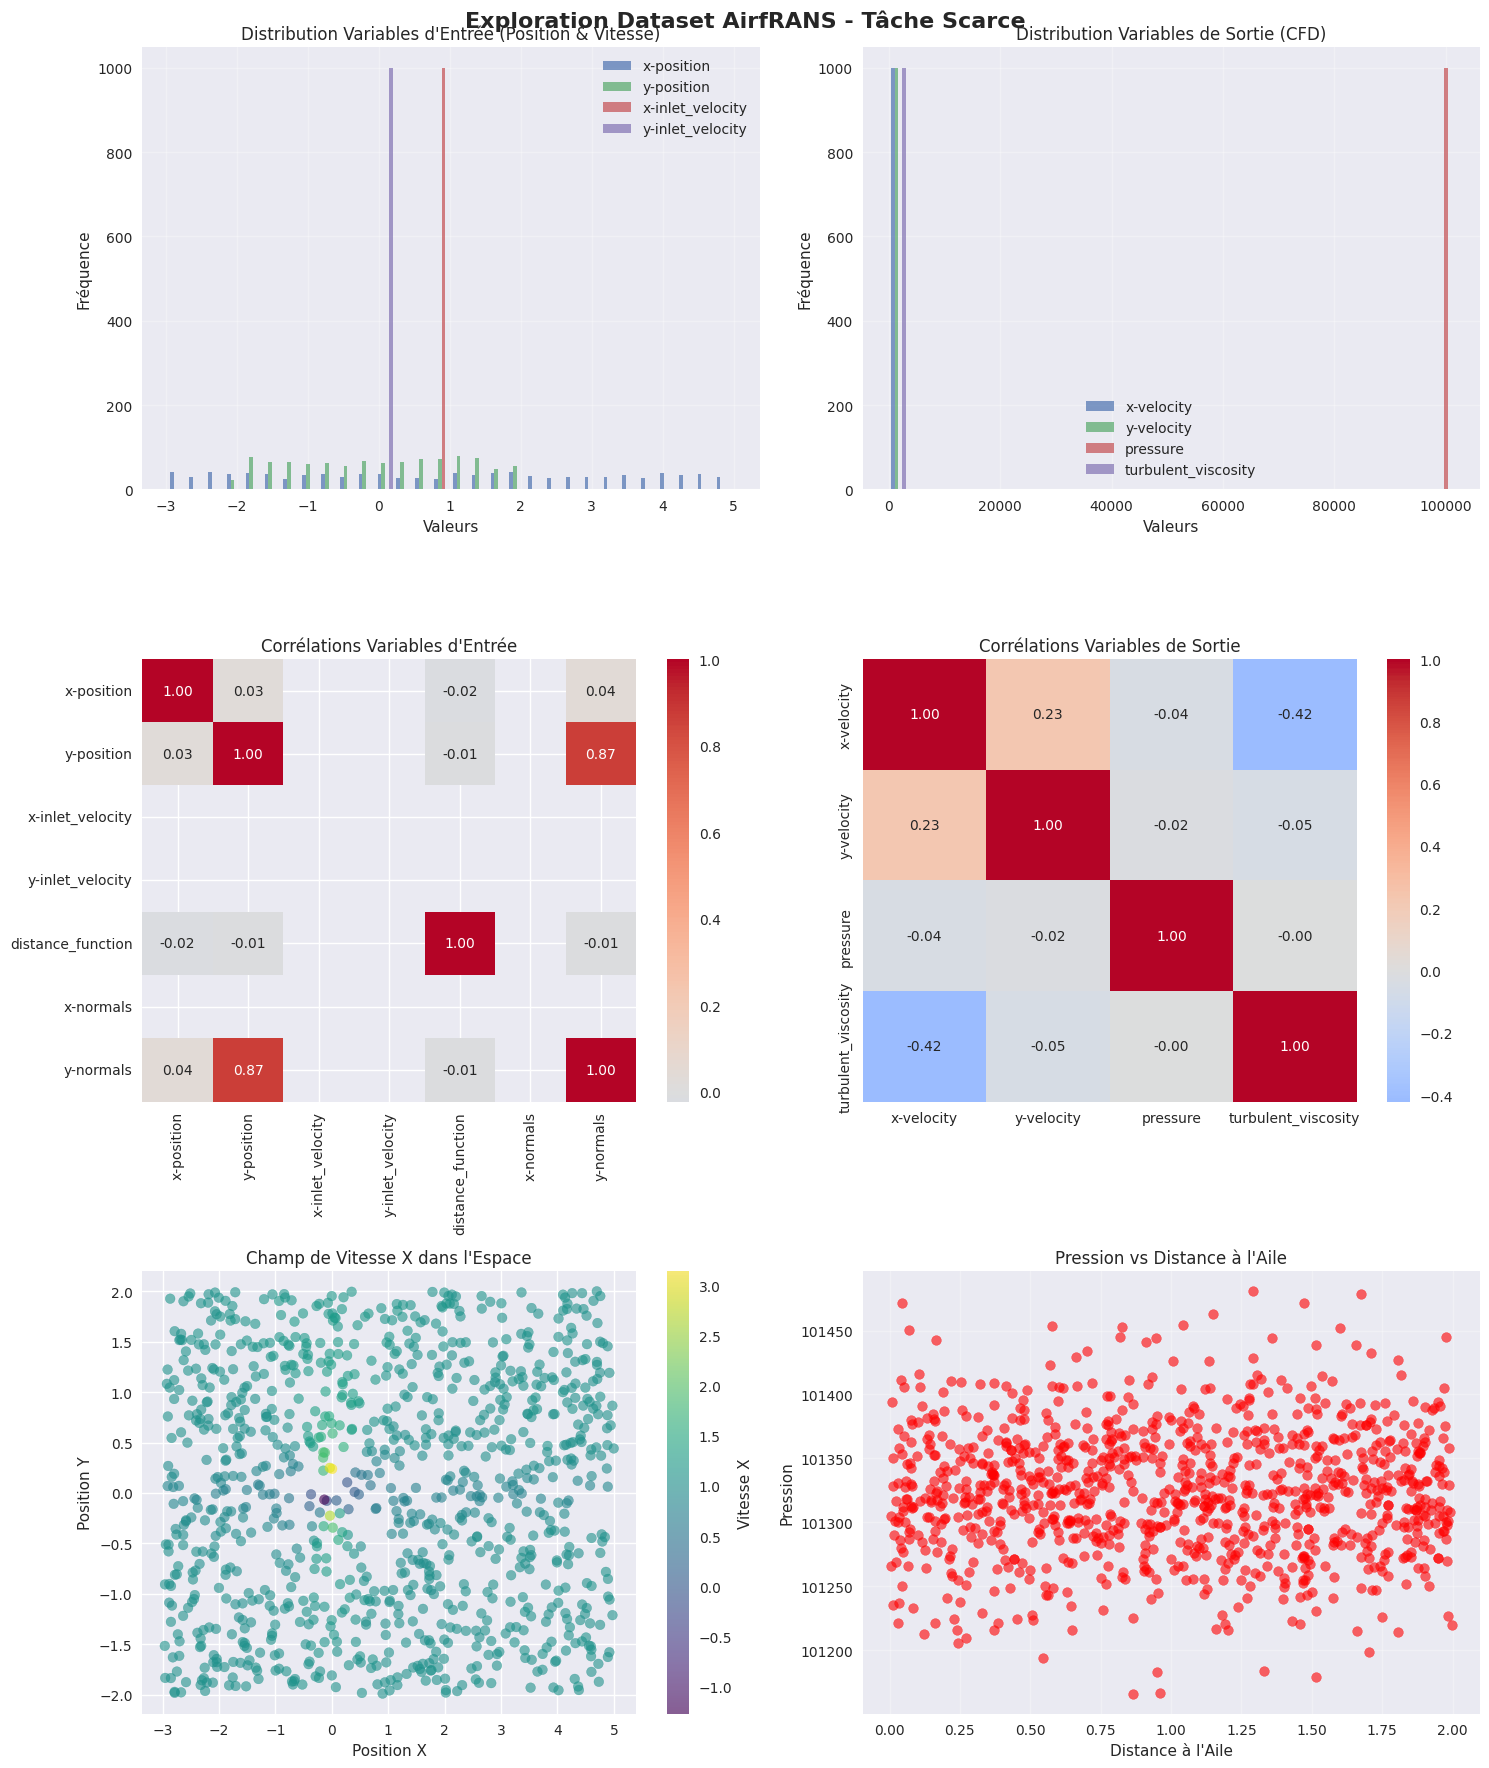

In [34]:
##VISUALISATIONS EXPLORATOIRES

def create_exploration_plots(df, attr_x, attr_y):
    """Créer des visualisations exploratoires"""
    
    fig, axes = plt.subplots(3, 2, figsize=(15, 18))
    fig.suptitle('Exploration Dataset AirfRANS - Tâche Scarce', fontsize=16, fontweight='bold')
    
    # 1. Distribution des variables d'entrée
    axes[0,0].hist([df[attr] for attr in attr_x[:4]], 
                   bins=30, alpha=0.7, label=attr_x[:4])
    axes[0,0].set_title('Distribution Variables d\'Entrée (Position & Vitesse)')
    axes[0,0].set_xlabel('Valeurs')
    axes[0,0].set_ylabel('Fréquence')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # 2. Distribution des variables de sortie
    axes[0,1].hist([df[attr] for attr in attr_y], 
                   bins=30, alpha=0.7, label=attr_y)
    axes[0,1].set_title('Distribution Variables de Sortie (CFD)')
    axes[0,1].set_xlabel('Valeurs') 
    axes[0,1].set_ylabel('Fréquence')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # 3. Corrélations entrées
    corr_x = df[list(attr_x)].corr()
    sns.heatmap(corr_x, annot=True, cmap='coolwarm', center=0, 
                ax=axes[1,0], fmt='.2f')
    axes[1,0].set_title('Corrélations Variables d\'Entrée')
    
    # 4. Corrélations sorties  
    corr_y = df[list(attr_y)].corr()
    sns.heatmap(corr_y, annot=True, cmap='coolwarm', center=0,
                ax=axes[1,1], fmt='.2f')
    axes[1,1].set_title('Corrélations Variables de Sortie')
    
    # 5. Relation Position vs Vitesse
    scatter = axes[2,0].scatter(df['x-position'], df['y-position'], 
                               c=df['x-velocity'], cmap='viridis', alpha=0.6)
    axes[2,0].set_xlabel('Position X')
    axes[2,0].set_ylabel('Position Y')
    axes[2,0].set_title('Champ de Vitesse X dans l\'Espace')
    plt.colorbar(scatter, ax=axes[2,0], label='Vitesse X')
    
    # 6. Relation Pression vs Distance
    axes[2,1].scatter(df['distance_function'], df['pressure'], 
                     alpha=0.6, color='red')
    axes[2,1].set_xlabel('Distance à l\'Aile')
    axes[2,1].set_ylabel('Pression')
    axes[2,1].set_title('Pression vs Distance à l\'Aile')
    axes[2,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Créer les visualisations
create_exploration_plots(df, attr_x, attr_y)


In [35]:

## ANALYSE DES PATTERNS PHYSIQUES

print(f"\n ANALYSE DES PATTERNS PHYSIQUES")
print("=" * 40)

# Analyser les relations physiques importantes
print(f" ANALYSE DU CHAMP DE VITESSE:")
velocity_magnitude = np.sqrt(df['x-velocity']**2 + df['y-velocity']**2)
print(f"   Vitesse moyenne: {velocity_magnitude.mean():.4f}")
print(f"   Vitesse max: {velocity_magnitude.max():.4f}")
print(f"   Vitesse min: {velocity_magnitude.min():.4f}")

print(f"\n ANALYSE DE LA PRESSION:")
print(f"   Pression moyenne: {df['pressure'].mean():.4f}")
print(f"   Pression max: {df['pressure'].max():.4f}")
print(f"   Pression min: {df['pressure'].min():.4f}")
print(f"   Écart-type: {df['pressure'].std():.4f}")

print(f"\n ANALYSE DE LA VISCOSITÉ TURBULENTE:")
print(f"   Viscosité moyenne: {df['turbulent_viscosity'].mean():.6f}")
print(f"   Viscosité max: {df['turbulent_viscosity'].max():.6f}")
print(f"   Points à viscosité nulle: {(df['turbulent_viscosity'] == 0).sum()}")


 ANALYSE DES PATTERNS PHYSIQUES
 ANALYSE DU CHAMP DE VITESSE:
   Vitesse moyenne: 0.9939
   Vitesse max: 4.0344
   Vitesse min: 0.1277

 ANALYSE DE LA PRESSION:
   Pression moyenne: 101324.0441
   Pression max: 101480.6637
   Pression min: 101165.9946
   Écart-type: 49.4911

 ANALYSE DE LA VISCOSITÉ TURBULENTE:
   Viscosité moyenne: 0.000209
   Viscosité max: 0.001340
   Points à viscosité nulle: 51


In [36]:


##COMPARAISON RAPIDE ENTRE TÂCHES

print(f"\n COMPARAISON RAPIDE ENTRE TÂCHES")
print("=" * 40)

def quick_task_comparison():
    """Comparaison rapide des différentes tâches"""
    
    task_stats = {}
    
    for task in ['scarce', 'full']:
        try:
            print(f" Chargement tâche '{task}'...")
            
            dataset_temp = AirfRANSDataSet(
                config=None,
                name=f"airfrans_{task}",
                task=task,
                split="training", 
                attr_names=attr_names,
                attr_x=attr_x,
                attr_y=attr_y,
                log_path="comparison_log"
            )
            
            dataset_temp.load(path=DIRECTORY_NAME)
            
            # Statistiques de base
            temp_data = {}
            for attr in attr_y:  # Analyser seulement les sorties
                if attr in dataset_temp.data:
                    temp_data[attr] = dataset_temp.data[attr]
            
            df_temp = pd.DataFrame(temp_data)
            
            task_stats[task] = {
                'n_samples': len(dataset_temp),
                'pressure_mean': df_temp['pressure'].mean(),
                'pressure_std': df_temp['pressure'].std(),
                'velocity_mean': np.sqrt(df_temp['x-velocity']**2 + df_temp['y-velocity']**2).mean()
            }
            
        except Exception as e:
            print(f" Erreur avec tâche '{task}': {e}")
            task_stats[task] = {'error': str(e)}
    
    return task_stats

# Exécuter la comparaison
comparison_stats = quick_task_comparison()

print(f"\n RÉSULTATS COMPARAISON:")
for task, stats in comparison_stats.items():
    if 'error' not in stats:
        print(f"\n{task.upper()}:")
        print(f"   Échantillons: {stats['n_samples']}")
        print(f"   Pression moyenne: {stats['pressure_mean']:.4f}")
        print(f"   Pression écart-type: {stats['pressure_std']:.4f}")
        print(f"   Vitesse moyenne: {stats['velocity_mean']:.4f}")


 COMPARAISON RAPIDE ENTRE TÂCHES
 Chargement tâche 'scarce'...
 Erreur avec tâche 'scarce': [Errno 2] No such file or directory: 'Dataset/manifest.json'
 Chargement tâche 'full'...
 Erreur avec tâche 'full': [Errno 2] No such file or directory: 'Dataset/manifest.json'

 RÉSULTATS COMPARAISON:


In [37]:


## RÉSUMÉ ET RECOMMANDATIONS

print(f"\n RÉSUMÉ DE L'EXPLORATION")
print("=" * 40)

print(f" DATASET AIRFRANS ANALYSÉ:")
print(f"   • Format: {len(attr_x)} entrées → {len(attr_y)} sorties")
print(f"   • Tâche 'scarce': données limitées pour test réaliste")
print(f"   • Variables physiques: position, vitesse, pression, viscosité")

print(f"\n OBSERVATIONS CLÉS:")
print(f"   • Champ de vitesse varie selon la position")
print(f"   • Pression corrélée à la distance de l'aile")
print(f"   • Viscosité turbulente concentrée près de l'aile")

print(f"\n RECOMMANDATIONS POUR MODÉLISATION:")
print(f"   • Normaliser les variables (échelles différentes)")
print(f"   • Attention aux relations position-vitesse")
print(f"   • Considérer la physique dans l'architecture")

print(f"\n PROCHAINE ÉTAPE:")
print(f"   → Notebook 2: Entraîner un modèle baseline")
print(f"   → Test avec différentes architectures")
print(f"   → Évaluation avec métriques LIPS")

# Sauvegarder les statistiques pour usage ultérieur
df.to_csv('airfrans_scarce_stats.csv', index=False)
print(f"\n Statistiques sauvegardées dans 'airfrans_scarce_stats.csv'")

print(f"\n EXPLORATION TERMINÉE - Prêt pour la modélisation!")


 RÉSUMÉ DE L'EXPLORATION
 DATASET AIRFRANS ANALYSÉ:
   • Format: 7 entrées → 4 sorties
   • Tâche 'scarce': données limitées pour test réaliste
   • Variables physiques: position, vitesse, pression, viscosité

 OBSERVATIONS CLÉS:
   • Champ de vitesse varie selon la position
   • Pression corrélée à la distance de l'aile
   • Viscosité turbulente concentrée près de l'aile

 RECOMMANDATIONS POUR MODÉLISATION:
   • Normaliser les variables (échelles différentes)
   • Attention aux relations position-vitesse
   • Considérer la physique dans l'architecture

 PROCHAINE ÉTAPE:
   → Notebook 2: Entraîner un modèle baseline
   → Test avec différentes architectures
   → Évaluation avec métriques LIPS

 Statistiques sauvegardées dans 'airfrans_scarce_stats.csv'

 EXPLORATION TERMINÉE - Prêt pour la modélisation!
